<a href="https://colab.research.google.com/github/onvallejo35/Atlantic-Tech/blob/master/Copia_de_album_Qatar2022.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">Técnicatura Superior en Desarrollo de Software</div>
<br>
<div align="center">Estadistica y Probabilidades para el Desarrollo de Software</div>

<br>
<div align="center">
  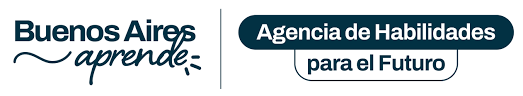
</div>
<br>

<div align="center">Completando el álbum del mundial</div>
<div align="center">Trabajo de simulación 2</div>

<br>

<div align="center">Integrantes del Grupo Comisión E</div> <br>
<div align="center">Nadiuska Padilla<br></div>
<div align="center">Nelson Bravo<br></div>
<div align="center">Oscar Vallejo<br></div>
<div align="center">Maximiliano Noguera<br></div>
<br><br>
Docente: Daniela Parada

<br>
<hr> <!-- Línea horizontal separadora -->

## Simulación: Álbum del Mundial Qatar 2022

Este ejercicio simula el llenado del álbum de figuritas del Mundial Qatar 2022 para estimar el promedio de paquetes necesarios para completarlo.

In [1]:
# Importamos las librerías necesarias
import random as rd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las constantes del problema
figus_total = 860
figus_paquete = 5

print(f"Figuritas totales en el álbum: {figus_total}")
print(f"Figuritas por paquete: {figus_paquete}")

Figuritas totales en el álbum: 860
Figuritas por paquete: 5


### 1. Experimento aleatorio: `cuantos_paquetes(figus_total, figus_paquete)`

implementamos las funciones auxiliares

#### a. `crear_album(figus_total)`

Esta función crea un nuevo álbum representado como un vector (lista) de ceros, donde cada posición corresponde a una figurita. Un `0` indica que la figurita no se tiene, y un `1` indicará que sí.

In [2]:
def crear_album(figus_total):
    return [0] * figus_total

# Ejemplo de uso:
album_ejemplo = crear_album(10)
print(f"Álbum de ejemplo (10 figuritas): {album_ejemplo}")

Álbum de ejemplo (10 figuritas): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


#### b. `comprar_paquete(figus_total, figus_paquete)`

Esta función simula la compra de un paquete, generando `figus_paquete` figuritas al azar. `rd.sample` se usa para asegurar que no haya figuritas repetidas dentro del mismo paquete, tal como afirma Panini.

In [3]:
def comprar_paquete(figus_total, figus_paquete):
    return rd.sample(range(figus_total), figus_paquete)

# Ejemplo de uso:
paquete_ejemplo = comprar_paquete(figus_total, figus_paquete)
print(f"Paquete de ejemplo: {paquete_ejemplo}")

Paquete de ejemplo: [818, 469, 805, 33, 93]


#### c. `pegar_figus(album, paquete)`

Esta función actualiza el `album` con las figuritas obtenidas en el `paquete`. Marca con un `1` las posiciones de las figuritas que ahora se tienen.

In [4]:
def pegar_figus(album, paquete):

    for figu in paquete:
        album[figu] = 1
    return album

album_prueba = crear_album(10)
paquete_prueba = comprar_paquete(10, 3)
print(f"Álbum antes de pegar: {album_prueba}")
print(f"Paquete a pegar: {paquete_prueba}")
album_despues = pegar_figus(album_prueba, paquete_prueba)
print(f"Álbum después de pegar: {album_despues}")

Álbum antes de pegar: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Paquete a pegar: [8, 9, 4]
Álbum después de pegar: [0, 0, 0, 0, 1, 0, 0, 0, 1, 1]


#### d. `album_incompleto(album)`

Esta función verifica si el álbum aún tiene figuritas faltantes (es decir, si contiene algún `0`).

In [5]:
def album_incompleto(album):
    return 0 in album

# Ejemplo de uso:
album_incompleto_ej = crear_album(5)
print(f"Álbum incompleto: {album_incompleto_ej}, ¿está incompleto? {album_incompleto(album_incompleto_ej)}")

album_completo_ej = [1] * 5
print(f"Álbum completo: {album_completo_ej}, ¿está incompleto? {album_incompleto(album_completo_ej)}")

Álbum incompleto: [0, 0, 0, 0, 0], ¿está incompleto? True
Álbum completo: [1, 1, 1, 1, 1], ¿está incompleto? False


#### e. `cuantos_paquetes(figus_total, figus_paquete)` (Función principal)

Esta función integra todas las anteriores para simular el proceso de llenar un álbum y cuenta cuántos paquetes fueron necesarios.

In [6]:
def cuantos_paquetes(figus_total, figus_paquete):

    album = crear_album(figus_total)
    paquetes_comprados = 0

    while album_incompleto(album):
        paquete = comprar_paquete(figus_total, figus_paquete)
        album = pegar_figus(album, paquete)
        paquetes_comprados += 1
    return paquetes_comprados

print(f"Paquetes necesarios para un álbum de 10 figuritas con 3 por paquete: {cuantos_paquetes(10, 3)}")

Paquetes necesarios para un álbum de 10 figuritas con 3 por paquete: 8


### 2. Muestra aleatoria

Realizamos la simulación $N=100$ veces para obtener una muestra de la cantidad de paquetes necesarios.

In [7]:
# Fijamos una semilla para reproducibilidad
rd.seed(42)
np.random.seed(42)

N = 100 # Número de repeticiones de la simulación
muestras = []

print(f"Iniciando simulación de {N} repeticiones...")
for i in range(N):
    paquetes = cuantos_paquetes(figus_total, figus_paquete)
    muestras.append(paquetes)
    if (i + 1) % 10 == 0: # Imprimir progreso cada 10 repeticiones
        print(f"Repetición {i+1}/{N} completada. Paquetes: {paquetes}")

print("Simulación completada.")

Iniciando simulación de 100 repeticiones...
Repetición 10/100 completada. Paquetes: 1204
Repetición 20/100 completada. Paquetes: 1171
Repetición 30/100 completada. Paquetes: 1142
Repetición 40/100 completada. Paquetes: 1049
Repetición 50/100 completada. Paquetes: 1461
Repetición 60/100 completada. Paquetes: 894
Repetición 70/100 completada. Paquetes: 1178
Repetición 80/100 completada. Paquetes: 1492
Repetición 90/100 completada. Paquetes: 1123
Repetición 100/100 completada. Paquetes: 1327
Simulación completada.


### 3. Estimación de paquetes para llenar el álbum

Estimamos el promedio de paquetes necesarios a partir de las `N` muestras obtenidas.

In [8]:
promedio_paquetes = np.mean(muestras)
print(f"Estimación del promedio de paquetes necesarios para completar el álbum (N={N} repeticiones): {promedio_paquetes:.2f}")

Estimación del promedio de paquetes necesarios para completar el álbum (N=100 repeticiones): 1277.02


### Histograma de la cantidad de paquetes

Visualizamos la distribución de la cantidad de paquetes necesarios utilizando un histograma.

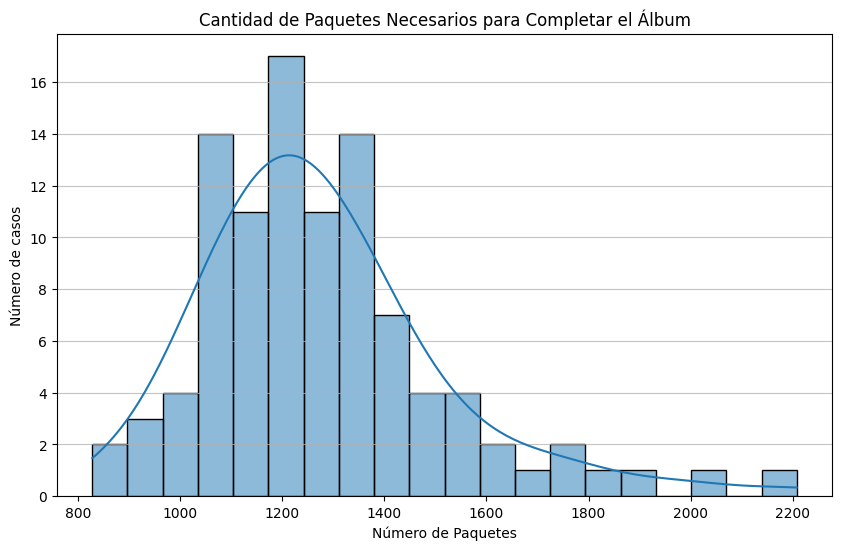

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(muestras, bins=20, kde=True)
plt.title('Cantidad de Paquetes Necesarios para Completar el Álbum')
plt.xlabel('Número de Paquetes')
plt.ylabel('Número de casos')
plt.grid(axis='y', alpha=0.75)
plt.show()

**CONCLUSIÓN**

A partir de las 100 simulaciones realizadas, se obtuvo, para este álbum de 860 figuritas con paquetes de 5 figuritas únicas cada uno, que en promedio, se necesitarian comprar alrededor de 1277 paquetes para completarlo. El histograma nos muestra cómo esta cantidad puede variar, y que se necesitarán menos paquetes y otras veces muchos más para alcanzar el objetivo.